In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)

# Plot Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [2]:
df = pd.read_excel(r"C:\Users\HP\Downloads\Delinquency_prediction_dataset.xlsx")

In [3]:
df_clean = df.copy()

In [4]:
missing_values = df_clean.isnull().sum()

missing_percentage = (missing_values / len(df_clean)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage": missing_percentage
})

missing_df[missing_df["Missing Count"] > 0]

,Missing Count,Missing Percentage
Income,39,7.8
Credit_Score,2,0.4
Loan_Balance,29,5.8


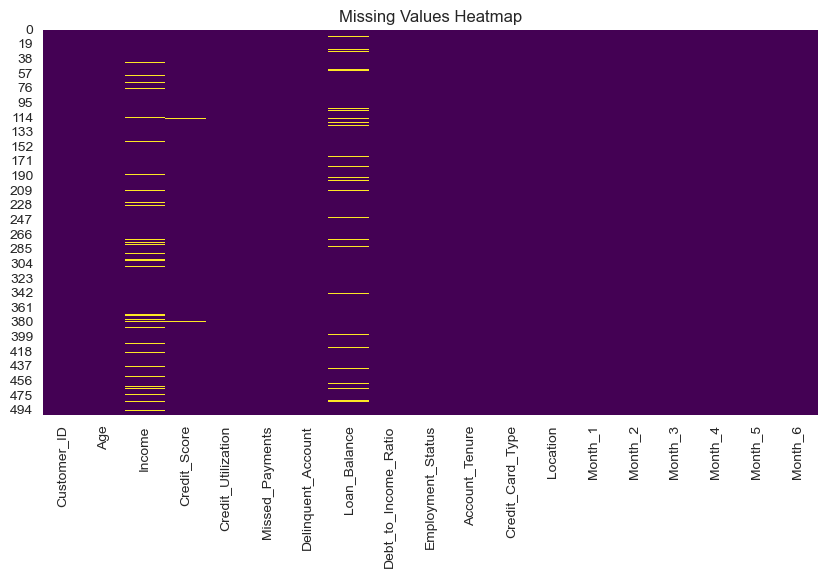

In [5]:
plt.figure(figsize=(10,5))
sns.heatmap(df_clean.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [6]:
df_clean["Income"] = df_clean["Income"].fillna(df_clean["Income"].median())

In [7]:
df_clean["Loan_Balance"] = df_clean["Loan_Balance"].fillna(df_clean["Loan_Balance"].median())

df_clean["Credit_Score"] = df_clean["Credit_Score"].fillna(df_clean["Credit_Score"].median())

In [8]:
df_clean.isnull().sum()

Customer_ID             0
Age                     0
Income                  0
Credit_Score            0
Credit_Utilization      0
Missed_Payments         0
Delinquent_Account      0
Loan_Balance            0
Debt_to_Income_Ratio    0
Employment_Status       0
Account_Tenure          0
Credit_Card_Type        0
Location                0
Month_1                 0
Month_2                 0
Month_3                 0
Month_4                 0
Month_5                 0
Month_6                 0
dtype: int64

In [9]:
df_clean.duplicated().sum()

np.int64(0)

In [10]:
df_clean.drop_duplicates(inplace=True)

In [11]:
df_clean.duplicated().sum()

np.int64(0)

In [12]:
df_clean.drop("Customer_ID", axis=1, inplace=True)

In [13]:
df_clean.columns

Index(['Age', 'Income', 'Credit_Score', 'Credit_Utilization',
       'Missed_Payments', 'Delinquent_Account', 'Loan_Balance',
       'Debt_to_Income_Ratio', 'Employment_Status', 'Account_Tenure',
       'Credit_Card_Type', 'Location', 'Month_1', 'Month_2', 'Month_3',
       'Month_4', 'Month_5', 'Month_6'],
      dtype='object')

In [14]:
df_clean.dtypes

Age                       int64
Income                  float64
Credit_Score            float64
Credit_Utilization      float64
Missed_Payments           int64
Delinquent_Account        int64
Loan_Balance            float64
Debt_to_Income_Ratio    float64
Employment_Status        object
Account_Tenure            int64
Credit_Card_Type         object
Location                 object
Month_1                  object
Month_2                  object
Month_3                  object
Month_4                  object
Month_5                  object
Month_6                  object
dtype: object

In [15]:
categorical_cols = df_clean.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df_clean[col].value_counts())


Employment_Status
Employment_Status
Unemployed       93
retired          87
Employed         82
EMP              81
Self-employed    80
employed         77
Name: count, dtype: int64

Credit_Card_Type
Credit_Card_Type
Gold        118
Student     112
Business    108
Standard     86
Platinum     76
Name: count, dtype: int64

Location
Location
Los Angeles    107
Phoenix        103
Chicago        103
Houston         95
New York        92
Name: count, dtype: int64

Month_1
Month_1
On-time    177
Missed     164
Late       159
Name: count, dtype: int64

Month_2
Month_2
Late       173
Missed     167
On-time    160
Name: count, dtype: int64

Month_3
Month_3
Late       169
On-time    169
Missed     162
Name: count, dtype: int64

Month_4
Month_4
Late       181
Missed     160
On-time    159
Name: count, dtype: int64

Month_5
Month_5
Missed     187
On-time    162
Late       151
Name: count, dtype: int64

Month_6
Month_6
Late       172
Missed     168
On-time    160
Name: count, dtype: int64


In [16]:
numerical_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns

numerical_cols

Index(['Age', 'Income', 'Credit_Score', 'Credit_Utilization',
       'Missed_Payments', 'Delinquent_Account', 'Loan_Balance',
       'Debt_to_Income_Ratio', 'Account_Tenure'],
      dtype='object')

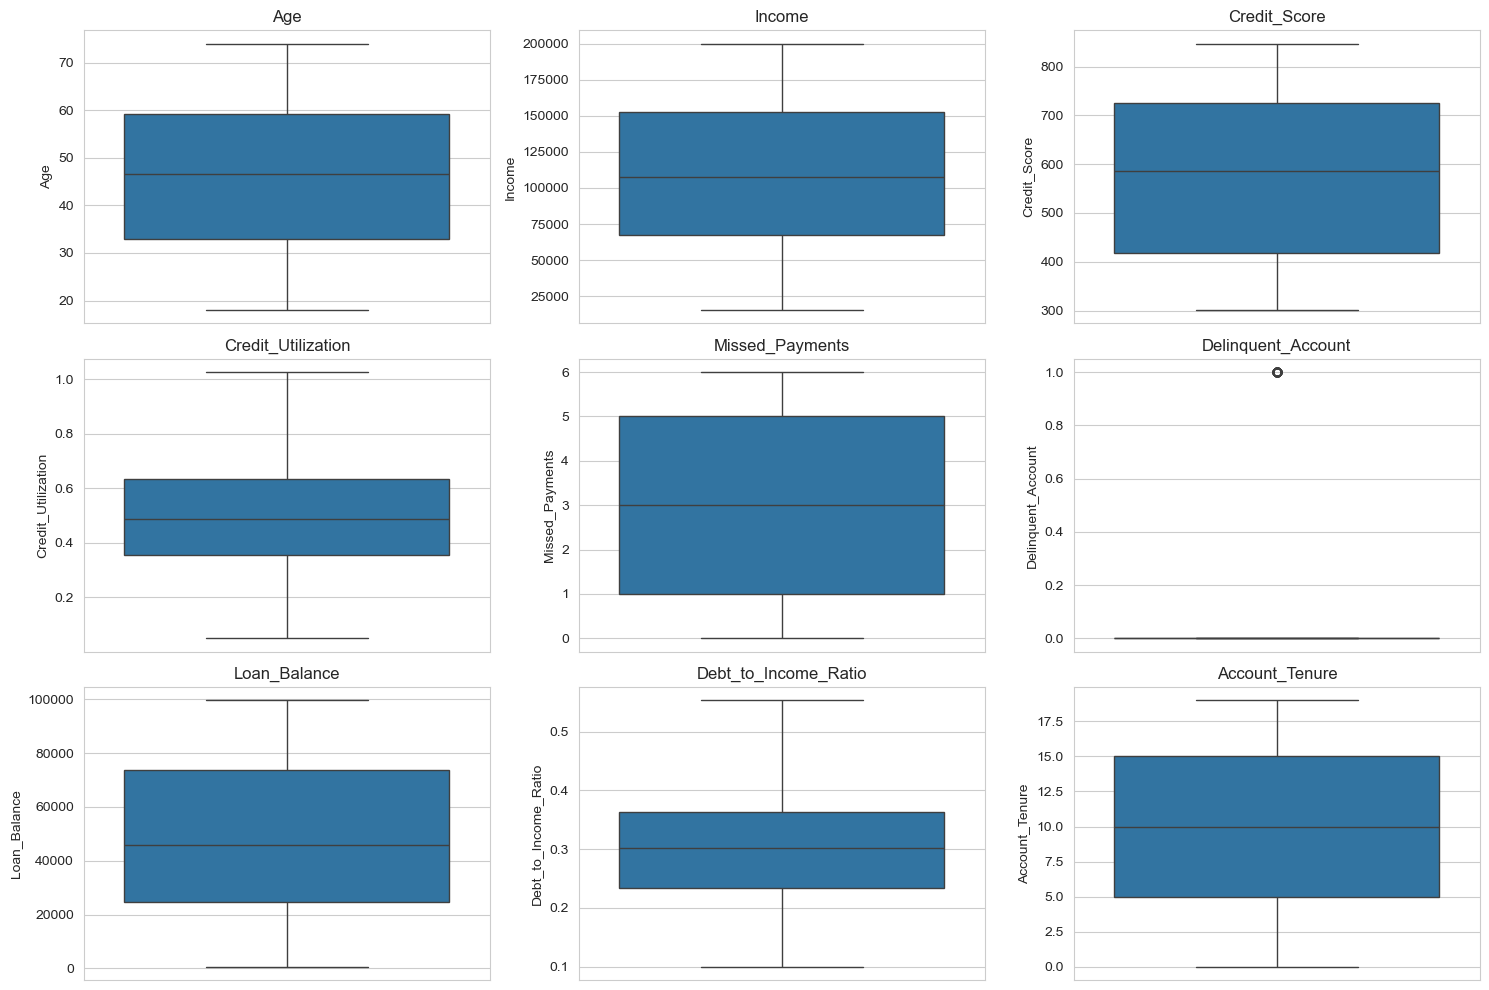

In [17]:
plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df_clean[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [18]:
Q1 = df_clean["Income"].quantile(0.25)
Q3 = df_clean["Income"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean["Income"] < lower) | (df_clean["Income"] > upper)]

print(outliers.shape)

(0, 18)


In [19]:
df_clean["Delinquent_Account"].value_counts()

Delinquent_Account
0    420
1     80
Name: count, dtype: int64

In [20]:
df_clean["Delinquent_Account"].value_counts(normalize=True) * 100

Delinquent_Account
0    84.0
1    16.0
Name: proportion, dtype: float64

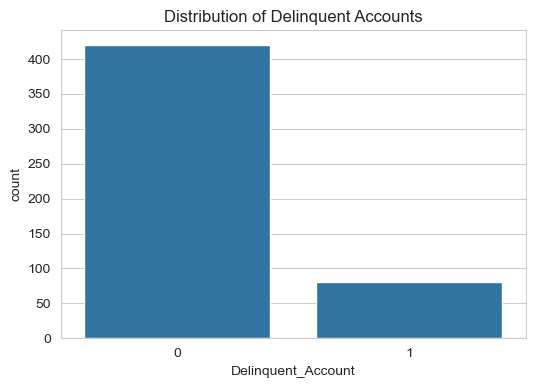

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x="Delinquent_Account", data=df_clean)
plt.title("Distribution of Delinquent Accounts")
plt.show()

In [22]:
df_clean.to_csv("cleaned_delinquency_dataset.csv", index=False)